# Lab 2 — KNN Classifier (Loan Default)

**Day 04 · Distance-Based ML & MLOps · Cisco AI/ML Training**

---

## Goals

1. Build a **scikit-learn Pipeline** with `StandardScaler` before `KNeighborsClassifier`.
2. Train a KNN model with **k = 5** on scaled numeric loan features.
3. Evaluate with **test accuracy** and inspect sample predictions.
4. Compare KNN (~0.55) to Day 3 logistic regression (~0.59).

> **Quick check:** train **800** / test **200** · k = **5** · accuracy ≈ **0.55** · preds include **0** and **1**

**Data:** `lending_club_sample.csv` — **1000** rows, same split as Day 3.

## K-Nearest Neighbors in one slide

KNN is a **lazy** learner — it stores training data and classifies by **majority vote** among the closest training points.

| Step | What happens |
|------|--------------|
| 1. Scale | Put every feature on comparable units (`StandardScaler`) |
| 2. Distance | Measure how far a test loan is from each training loan |
| 3. Vote | Pick the **k** nearest neighbors; majority class wins |

**Why scaling?** Without it, large-magnitude features (e.g. `annual_inc`) dominate distance — see Lab 1.

## KNN vs logistic regression (Day 3)

| Aspect | Logistic regression | KNN |
|--------|---------------------|-----|
| Decision boundary | Linear (sigmoid) | Local, data-driven |
| Training | Fits coefficients | Stores all training rows |
| Hyperparameter | Regularization C | **k** neighbors |
| Typical accuracy (this sample) | ~0.59 | ~0.55 at k=5 |

---

## 0. Locate data

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

**Step 2** — run the cell below and read the printed summary. <!-- cisco-split-debug-2026 -->

In [2]:
GH_ROOT = Path.cwd().resolve()
if GH_ROOT.name == "notebooks":
    GH_ROOT = GH_ROOT.parents[2]
elif (GH_ROOT.parent / "notebooks").is_dir() and (GH_ROOT.parents[1] / "requirements-student.txt").is_file():
    GH_ROOT = GH_ROOT.parents[1]
else:
    for parent in [GH_ROOT, *GH_ROOT.parents]:
        if (parent / "requirements-student.txt").is_file():
            GH_ROOT = parent
            break

LENDING_CLUB_CSV = GH_ROOT / "data" / "lending-club" / "lending_club_sample.csv"
DEFAULT_STATUSES = {"Charged Off", "Late (31-120 days)"}
NUMERIC_FEATURES = ["loan_amnt", "int_rate", "annual_inc", "dti", "installment"]

print("CSV:", LENDING_CLUB_CSV.name)
print("Exists:", LENDING_CLUB_CSV.is_file())

CSV: lending_club_sample.csv
Exists: True


---

## 1. Load data and select features

In [3]:
df = pd.read_csv(LENDING_CLUB_CSV)
df["default"] = df["loan_status"].isin(DEFAULT_STATUSES).astype(int)

X = df[NUMERIC_FEATURES]
y = df["default"]

print(f"rows: {len(df)}")
print(f"default rate: {y.mean():.4f}")
display(X.head(3))


rows: 1000
default rate: 0.4850


,loan_amnt,int_rate,annual_inc,dti,installment
0,34498,14.50,35829,15.66,98.07
1,33265,6.75,105184,5.91,859.60
2,4012,6.48,139128,13.90,320.56


### 1b. Class balance

In [4]:
balance = y.value_counts().rename({0: "no default", 1: "default"})
print(balance)
print(f"minority class share: {y.mean():.2%}")


default
no default    515
default       485
Name: count, dtype: int64
minority class share: 48.50%


### 1c. Feature correlation with default

In [5]:
corr_default = X.assign(default=y).corr(numeric_only=True)["default"].drop("default")
display(corr_default.sort_values(key=abs, ascending=False).round(4).to_frame("corr"))


,corr
int_rate,0.2084
dti,0.1530
installment,-0.0608
annual_inc,-0.0112
loan_amnt,-0.0056


---

## 2. Train/test split with stratification

`stratify=y` keeps the same default rate in train and test — same split settings as Day 3 for fair comparison.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"train size: {len(X_train)}")
print(f"test size:  {len(X_test)}")
print(f"default rate (train): {y_train.mean():.4f}")
print(f"default rate (test):  {y_test.mean():.4f}")

assert len(X_train) == 800 and len(X_test) == 200


train size: 800
test size:  200
default rate (train): 0.4850
default rate (test):  0.4850


### 2b. Verify stratification preserved rates

In [7]:
rate_diff = abs(y_train.mean() - y_test.mean())
print(f"train vs test default rate gap: {rate_diff:.6f} (should be tiny)")


train vs test default rate gap: 0.000000 (should be tiny)


---

## 3. Pipeline: scale → KNN (k = 5)

The pipeline ensures scaling is **fit on train only** and applied consistently at predict time.

In [8]:
K = 5

pipe = Pipeline(
    steps=[
        ("scale", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=K)),
    ]
)

print(pipe)


Pipeline(steps=[('scale', StandardScaler()), ('knn', KNeighborsClassifier())])

### 3b. Inspect pipeline steps

In [9]:
for name, step in pipe.steps:
    print(f"{name}: {step.__class__.__name__}")


scale: StandardScaler


knn: KNeighborsClassifier


### 3c. What StandardScaler does (preview)

In [10]:
scaler_preview = StandardScaler()
scaled_train = scaler_preview.fit_transform(X_train)
print("scaled train mean (≈0):", np.round(scaled_train.mean(axis=0), 3))
print("scaled train std  (≈1):", np.round(scaled_train.std(axis=0), 3))


scaled train mean (≈0): [-0.  0.  0. -0.  0.]
scaled train std  (≈1): [1. 1. 1. 1. 1.]


---

## 4. Fit and evaluate

In [11]:
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Lab 2 — KNN classifier")
print(f"k (neighbors): {K}")
print(f"test accuracy: {accuracy:.4f}")
print(f"sample predictions (first 5): {y_pred[:5].tolist()}")


Lab 2 — KNN classifier
k (neighbors): 5
test accuracy: 0.5500
sample predictions (first 5): [1, 0, 1, 0, 1]


### 4b. `predict_proba` — soft scores

In [12]:
proba = pipe.predict_proba(X_test[:3])
print("P(default) for first 3 test loans:")
for i, p in enumerate(proba):
    print(f"  loan {i}: P(no default)={p[0]:.3f}, P(default)={p[1]:.3f}")


P(default) for first 3 test loans:
  loan 0: P(no default)=0.000, P(default)=1.000
  loan 1: P(no default)=0.600, P(default)=0.400
  loan 2: P(no default)=0.400, P(default)=0.600


### 4c. Sample predictions vs actual

In [13]:
sample = pd.DataFrame({
    "int_rate": X_test.iloc[:5]["int_rate"].values,
    "dti": X_test.iloc[:5]["dti"].values,
    "predicted": y_pred[:5],
    "actual": y_test.iloc[:5].values,
})
display(sample)

unique_preds = set(y_pred.tolist())
print(f"unique predicted labels: {sorted(unique_preds)}")
assert 0 in unique_preds and 1 in unique_preds


,int_rate,dti,predicted,actual
0,18.69,26.05,1,1
1,8.89,22.20,0,0
2,20.72,18.75,1,1
3,13.04,6.46,0,0
4,14.84,22.04,1,1


unique predicted labels: [0, 1]


---

## 5. Confusion matrix

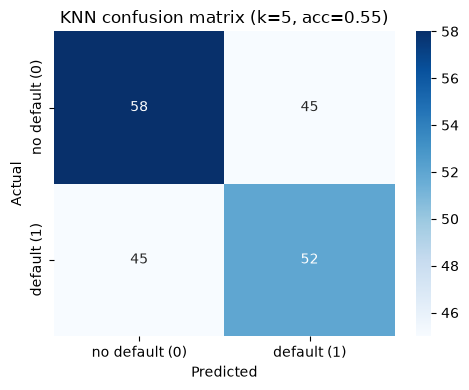

In [14]:
cm = confusion_matrix(y_test, y_pred)
labels = ["no default (0)", "default (1)"]

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"KNN confusion matrix (k={K}, acc={accuracy:.2f})")
plt.tight_layout()
plt.show()


### 5b. Confusion matrix as DataFrame

In [15]:
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
display(cm_df)
tn, fp, fn, tp = cm.ravel()
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")


,no default (0),default (1)
no default (0),58,45
default (1),45,52


TN=58, FP=45, FN=45, TP=52


Accuracy ≈ **0.55** is modest — KNN with k=5 is a useful baseline, but Lab 3 will show whether a different **k** improves it.

---

## 6. Error analysis — misclassified loans

In [16]:
mis_idx = np.where(y_pred != y_test.values)[0][:5]
if len(mis_idx):
    err = X_test.iloc[mis_idx].copy()
    err["actual"] = y_test.iloc[mis_idx].values
    err["predicted"] = y_pred[mis_idx]
    display(err.round(2))
else:
    print("No misclassifications (unlikely at k=5).")


,loan_amnt,int_rate,annual_inc,dti,installment,actual,predicted
768,11714,7.28,157612,23.92,732.75,1,0
406,33782,6.05,37461,13.97,157.52,0,1
23,19326,14.39,171459,27.02,293.44,1,0
352,17451,16.76,140262,8.50,775.56,1,0
795,15522,12.01,106756,26.35,410.71,1,0


---

## 7. Compare to Day 3 logistic regression

| Model | Typical test accuracy (this sample) |
|-------|-------------------------------------|
| Logistic regression (Day 3) | ~**0.59** |
| KNN k=5 (this lab) | ~**0.55** |

Linear models can outperform KNN when the decision boundary is roughly linear and features are well chosen.

### 7b. Why KNN might underperform here

In [17]:
print("Possible reasons KNN k=5 < logistic regression:")
print("  • k=5 may not be optimal (Lab 3 sweeps k)")
print("  • Only 5 numeric features — linear boundary may suffice")
print("  • Class overlap in feature space — local votes are noisy")


Possible reasons KNN k=5 < logistic regression:
  • k=5 may not be optimal (Lab 3 sweeps k)
  • Only 5 numeric features — linear boundary may suffice
  • Class overlap in feature space — local votes are noisy


---

## 8. Distance intuition on scaled space

In [18]:
# One test point vs its nearest training neighbor (scaled)
scaled_X_train = pipe.named_steps["scale"].transform(X_train)
scaled_test_0 = pipe.named_steps["scale"].transform(X_test.iloc[[0]])
dists = np.linalg.norm(scaled_X_train - scaled_test_0, axis=1)
nn_idx = int(np.argmin(dists))
print(f"Nearest training loan to test[0]: index {nn_idx}, distance={dists[nn_idx]:.3f}")
print(f"That neighbor's label: {y_train.iloc[nn_idx]}")
print(f"Model prediction for test[0]: {y_pred[0]}")


Nearest training loan to test[0]: index 380, distance=0.773
That neighbor's label: 1
Model prediction for test[0]: 1


### 8b. k=5 neighbor count intuition

In [19]:
print(f"With k={K}, each prediction uses {K} of {len(X_train)} training loans.")
print("Odd k avoids tie votes in binary classification.")


With k=5, each prediction uses 5 of 800 training loans.
Odd k avoids tie votes in binary classification.


### 8c. Feature importance proxy — permutation-free

In [20]:
# Quick univariate signal: absolute correlation with default on train set
uni = X_train.assign(default=y_train.values).corr(numeric_only=True)["default"].drop("default")
display(uni.abs().sort_values(ascending=False).round(4).to_frame("abs_corr"))


,abs_corr
int_rate,0.2035
dti,0.1538
installment,0.0778
loan_amnt,0.0397
annual_inc,0.0170


### 8d. Accuracy by predicted class

In [21]:
for label in [0, 1]:
    mask = y_pred == label
    if mask.any():
        class_acc = (y_pred[mask] == y_test.values[mask]).mean()
        print(f"predicted {label}: {mask.sum()} rows, accuracy within class {class_acc:.3f}")


predicted 0: 103 rows, accuracy within class 0.563
predicted 1: 97 rows, accuracy within class 0.536


### 8e. Save pipeline with joblib (preview)

In [22]:
import joblib
# joblib.dump(pipe, "knn_k5_pipeline.joblib")  # uncomment to persist
print("Pipeline steps ready for serialization:", [s[0] for s in pipe.steps])


Pipeline steps ready for serialization: ['scale', 'knn']


### 8f. Weighted vs uniform KNN

In [23]:
# KNeighborsClassifier supports distance weighting
pipe_dist = Pipeline([
    ("scale", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=K, weights="distance")),
])
pipe_dist.fit(X_train, y_train)
acc_dist = accuracy_score(y_test, pipe_dist.predict(X_test))
print(f"uniform weights accuracy: {accuracy:.4f}")
print(f"distance weights accuracy: {acc_dist:.4f}")


uniform weights accuracy: 0.5500
distance weights accuracy: 0.5750


### 8g. Classification report

In [24]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=["no default", "default"]))


              precision    recall  f1-score   support

  no default       0.56      0.56      0.56       103
     default       0.54      0.54      0.54        97

    accuracy                           0.55       200
   macro avg       0.55      0.55      0.55       200
weighted avg       0.55      0.55      0.55       200



---

## 9. Try it yourself

1. Predict with `k=1` on the same split — is accuracy higher or lower?
2. Does `predict_proba` for the first test loan exceed 0.5?

In [25]:
# Your code here (optional)


In [26]:
pipe_k1 = Pipeline([
    ("scale", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=1)),
])
pipe_k1.fit(X_train, y_train)
acc_k1 = accuracy_score(y_test, pipe_k1.predict(X_test))
print(f"k=1 accuracy: {acc_k1:.4f} vs k=5: {accuracy:.4f}")


k=1 accuracy: 0.5700 vs k=5: 0.5500


---

## 10. Checkpoint summary

In [27]:
assert len(X_train) == 800 and len(X_test) == 200
assert K == 5
assert abs(accuracy - 0.55) < 0.02
assert y_pred[:5].tolist() == [1, 0, 1, 0, 1]
print("Numbers match — you're good.")



Numbers match — you're good.


---

## Reflection

1. Why must `StandardScaler` come **before** KNN in the pipeline?
2. What happens if k=1? What if k equals the full training set size?
3. Would adding categorical features (grade, term) help without encoding?
